# Supervised Learning Assignment

### Mushroom Dataset Loading

In [1]:
import pandas as pd

mushrooms_dataframe = pd.read_csv(
    "./mushrooms.csv",
    sep=";"
)



# separating the features from the target variable
x = mushrooms_dataframe.drop("class", axis=1)
y = mushrooms_dataframe["class"]

# handling missing values by filling them with the mode of each column
for col in mushrooms_dataframe.columns:
    mushrooms_dataframe[col] = mushrooms_dataframe[col].fillna(mushrooms_dataframe[col].mode()[0])


### from categories to numbers


In [2]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for column in x.columns:
    x[column] = le.fit_transform(x[column])

y = le.fit_transform(y)


### Data Division (Training, Testing)

In [ ]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y,
)


(138, 22)

## Experiment 0: Baseline (All Features + Naive Bayes)

### Model Training

In [4]:
from sklearn.naive_bayes import CategoricalNB

# Ensure every feature can represent all encoded categories seen in the full dataset.
min_categories = x.max(axis=0).to_numpy() + 1

model = CategoricalNB(min_categories=min_categories)

model.fit(x_train, y_train)

,alpha,1.0
,force_alpha,True
,fit_prior,True
,class_prior,None
,min_categories,"array([ 23, 1... 9, 21, 10])"


### Prediction

In [5]:
y_baseline_pred = model.predict(x_test)


### Accuracy Evaluation

In [6]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_baseline_pred)
print(f"Accuracy: {accuracy:.2f}")

Accuracy: 0.71


### Classification Report

In [7]:
from sklearn.metrics import classification_report

report = classification_report(y_test, y_baseline_pred)
print(report)

              precision    recall  f1-score   support

           0       0.64      0.88      0.74        16
           1       0.85      0.58      0.69        19

    accuracy                           0.71        35
   macro avg       0.74      0.73      0.71        35
weighted avg       0.75      0.71      0.71        35



### Confusion Matrix

In [8]:
from sklearn.metrics import confusion_matrix

conf_matrix = confusion_matrix(y_test, y_baseline_pred)
print("Confusion Matrix:")
print(conf_matrix)

Confusion Matrix:
[[14  2]
 [ 8 11]]


## Experiment A: Feature Selection + Naive Bayes

### Feature Selection (3 features)

In [9]:
from sklearn.feature_selection import SelectKBest, chi2

selector = SelectKBest(score_func=chi2, k=3)

x_train_selected = selector.fit_transform(x_train, y_train)
x_test_selected = selector.transform(x_test)


### Model Training

In [10]:
from sklearn.naive_bayes import CategoricalNB

# Use only the selected feature indices so min_categories length matches x_train_selected shape.
selected_indices = selector.get_support(indices=True)
min_categories = x.iloc[:, selected_indices].max(axis=0).to_numpy() + 1

model = CategoricalNB(min_categories=min_categories)

model.fit(x_train_selected, y_train)

,alpha,1.0
,force_alpha,True
,fit_prior,True
,class_prior,None
,min_categories,"array([173, 27, 46])"


### Prediction

In [11]:
y_feature_selection_pred = model.predict(x_test_selected)

### Accuracy Evaluation

In [12]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_feature_selection_pred)
print(f"Accuracy: {accuracy:.2f}")

Accuracy: 0.63


### Classification Report

In [13]:
from sklearn.metrics import classification_report

report = classification_report(y_test, y_feature_selection_pred)
print(report)

              precision    recall  f1-score   support

           0       0.60      0.56      0.58        16
           1       0.65      0.68      0.67        19

    accuracy                           0.63        35
   macro avg       0.62      0.62      0.62        35
weighted avg       0.63      0.63      0.63        35



### Confusion Matrix

In [14]:
from sklearn.metrics import confusion_matrix

conf_matrix = confusion_matrix(y_test, y_feature_selection_pred)
print("Confusion Matrix:")
print(conf_matrix)

Confusion Matrix:
[[ 9  7]
 [ 6 13]]


## Experiment B: PCA (Feature Reduction) + Naive Bayes

### PCA From Scratch (importing Class Implementation from external files)

In [15]:
import numpy as np
from PCA_implementation import PCA

### Scree Plot — Choose Best K

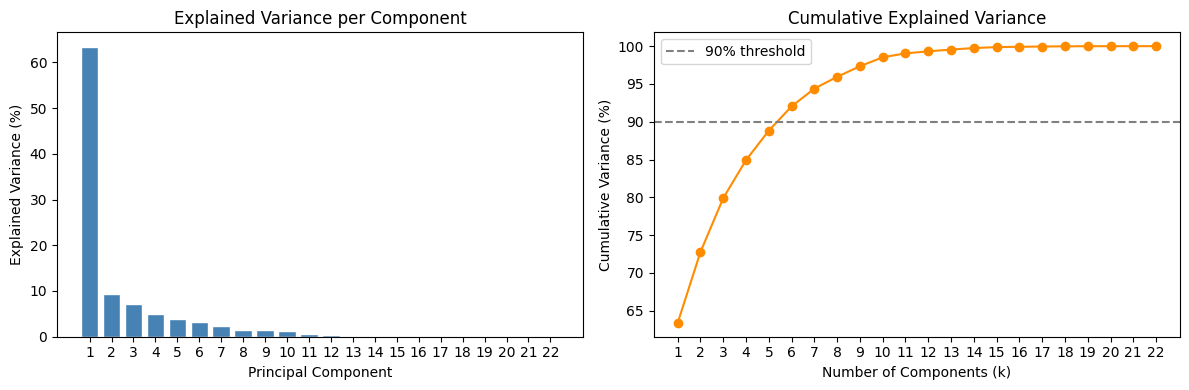


Eigenvalues: [2.5851045e+03 3.8258840e+02 2.9042010e+02 2.0532740e+02 1.5855220e+02
 1.3100690e+02 9.5857000e+01 6.3332000e+01 5.7186100e+01 4.8143200e+01
 2.1197500e+01 1.1077400e+01 9.3888000e+00 8.2581000e+00 5.1433000e+00
 1.6922000e+00 1.4363000e+00 9.2700000e-01 7.9060000e-01 9.9500000e-02
 6.8100000e-02 2.0600000e-02]
Explained Variance Ratio: [6.34e-01 9.38e-02 7.12e-02 5.04e-02 3.89e-02 3.21e-02 2.35e-02 1.55e-02
 1.40e-02 1.18e-02 5.20e-03 2.70e-03 2.30e-03 2.00e-03 1.30e-03 4.00e-04
 4.00e-04 2.00e-04 2.00e-04 0.00e+00 0.00e+00 0.00e+00]
Cumulative: [0.634  0.7278 0.799  0.8494 0.8883 0.9204 0.9439 0.9594 0.9735 0.9853
 0.9905 0.9932 0.9955 0.9975 0.9988 0.9992 0.9995 0.9998 1.     1.
 1.     1.    ]


In [16]:
import matplotlib.pyplot as plt

X_all = x_train.to_numpy().astype(float)

pca_full = PCA(n_components=x_train.shape[1])
pca_full.fit(X_all)

evr  = pca_full.explained_variance_ratio_
cumulative = np.cumsum(evr)
ks   = range(1, len(evr) + 1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Individual variance per component
axes[0].bar(ks, evr * 100, color='steelblue', edgecolor='white')
axes[0].set_title('Explained Variance per Component')
axes[0].set_xlabel('Principal Component')
axes[0].set_ylabel('Explained Variance (%)')
axes[0].set_xticks(list(ks))

# Cumulative variance
axes[1].plot(ks, cumulative * 100, 'o-', color='darkorange')
axes[1].axhline(90, color='gray', linestyle='--', label='90% threshold')
axes[1].set_title('Cumulative Explained Variance')
axes[1].set_xlabel('Number of Components (k)')
axes[1].set_ylabel('Cumulative Variance (%)')
axes[1].set_xticks(list(ks))
axes[1].legend()

plt.tight_layout()
plt.show()

print('\nEigenvalues:', np.round(pca_full.eigenvalues_, 4))
print('Explained Variance Ratio:', np.round(evr, 4))
print('Cumulative:', np.round(cumulative, 4))

### Try Multiple Values of K — Find Best

In [17]:
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score

X_train_np = x_train.to_numpy().astype(float)
X_test_np  = x_test.to_numpy().astype(float)

k_values    = list(range(1, x_train.shape[1] + 1))
k_accuracies = []

for k in k_values:
    pca = PCA(n_components=k)
    X_train_pca = pca.fit_transform(X_train_np)
    X_test_pca  = pca.transform(X_test_np)

    # GaussianNB used because PCA output is continuous (not categorical)
    gnb = GaussianNB()
    gnb.fit(X_train_pca, y_train)
    acc = accuracy_score(y_test, gnb.predict(X_test_pca))
    k_accuracies.append(acc)
    print(f'k={k:2d}  ->  Accuracy: {acc:.2f}')

best_k   = k_values[np.argmax(k_accuracies)]
best_acc = max(k_accuracies)
print(f'\nBest k = {best_k}  |  Best Accuracy = {best_acc:.2f}')

k= 1  ->  Accuracy: 0.57
k= 2  ->  Accuracy: 0.57
k= 3  ->  Accuracy: 0.60
k= 4  ->  Accuracy: 0.60
k= 5  ->  Accuracy: 0.60
k= 6  ->  Accuracy: 0.63
k= 7  ->  Accuracy: 0.57
k= 8  ->  Accuracy: 0.66
k= 9  ->  Accuracy: 0.69
k=10  ->  Accuracy: 0.66
k=11  ->  Accuracy: 0.60
k=12  ->  Accuracy: 0.66
k=13  ->  Accuracy: 0.60
k=14  ->  Accuracy: 0.63
k=15  ->  Accuracy: 0.60
k=16  ->  Accuracy: 0.60
k=17  ->  Accuracy: 0.54
k=18  ->  Accuracy: 0.51
k=19  ->  Accuracy: 0.57
k=20  ->  Accuracy: 0.60
k=21  ->  Accuracy: 0.54
k=22  ->  Accuracy: 0.54

Best k = 9  |  Best Accuracy = 0.69


### Train & Evaluate with Best K

In [18]:
from sklearn.metrics import classification_report, confusion_matrix

pca_best = PCA(n_components=best_k)
X_train_pca = pca_best.fit_transform(X_train_np)
X_test_pca  = pca_best.transform(X_test_np)

gnb_best = GaussianNB()
gnb_best.fit(X_train_pca, y_train)
y_pred_pca = gnb_best.predict(X_test_pca)

print(f'Best k = {best_k}')
print(f'Accuracy: {accuracy_score(y_test, y_pred_pca):.2f}\n')
print(classification_report(y_test, y_pred_pca))
print('Confusion Matrix:')
print(confusion_matrix(y_test, y_pred_pca))

Best k = 9
Accuracy: 0.69

              precision    recall  f1-score   support

           0       0.65      0.69      0.67        16
           1       0.72      0.68      0.70        19

    accuracy                           0.69        35
   macro avg       0.68      0.69      0.68        35
weighted avg       0.69      0.69      0.69        35

Confusion Matrix:
[[11  5]
 [ 6 13]]


### Comparison: All Experiments

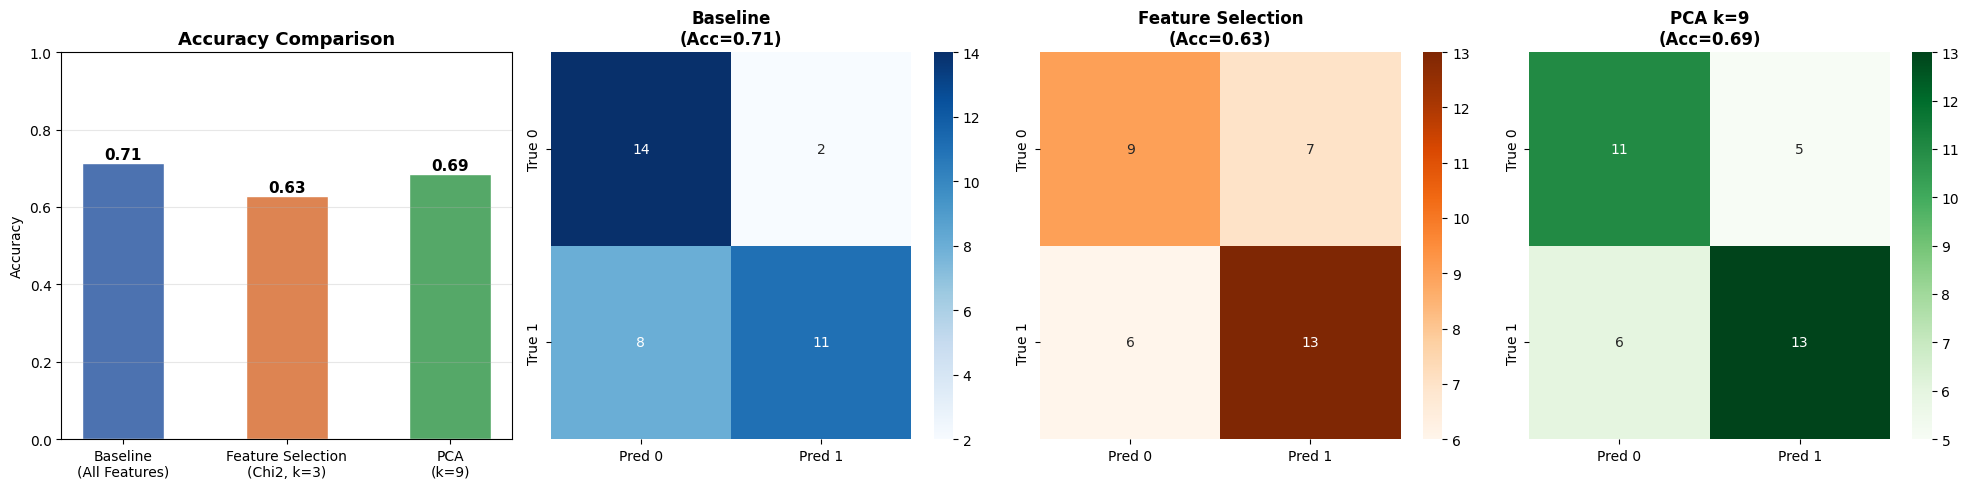

             Experiment  Accuracy  # Features/PCs
Baseline (All Features)  0.714286              22
Feature Selection (k=3)  0.628571               3
 PCA from Scratch (k=9)  0.685714               9


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.metrics import confusion_matrix, accuracy_score

acc_baseline = accuracy_score(y_test, y_baseline_pred)
acc_featsel  = accuracy_score(y_test, y_feature_selection_pred)
acc_pca      = accuracy_score(y_test, y_pred_pca)

labels = ['Baseline\n(All Features)', 'Feature Selection\n(Chi2, k=3)', f'PCA\n(k={best_k})']
accs   = [acc_baseline, acc_featsel, acc_pca]
colors = ['#4C72B0', '#DD8452', '#55A868']

fig, axes = plt.subplots(1, 4, figsize=(20, 5))

# ── Bar chart ──────────────────────────────────────────────────────
bars = axes[0].bar(labels, accs, color=colors, edgecolor='white', width=0.5)
for bar, acc in zip(bars, accs):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                 f'{acc:.2f}', ha='center', fontsize=11, fontweight='bold')
axes[0].set_ylim(0, 1.0)
axes[0].set_title('Accuracy Comparison', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Accuracy')
axes[0].grid(axis='y', alpha=0.3)

# ── Confusion Matrix — Baseline ────────────────────────────────────
sns.heatmap(confusion_matrix(y_test, y_baseline_pred), annot=True, fmt='d',
            cmap='Blues', ax=axes[1],
            xticklabels=['Pred 0','Pred 1'], yticklabels=['True 0','True 1'])
axes[1].set_title(f'Baseline\n(Acc={acc_baseline:.2f})', fontweight='bold')

# ── Confusion Matrix — Feature Selection ───────────────────────────
sns.heatmap(confusion_matrix(y_test, y_feature_selection_pred), annot=True, fmt='d',
            cmap='Oranges', ax=axes[2],
            xticklabels=['Pred 0','Pred 1'], yticklabels=['True 0','True 1'])
axes[2].set_title(f'Feature Selection\n(Acc={acc_featsel:.2f})', fontweight='bold')

# ── Confusion Matrix — PCA ─────────────────────────────────────────
sns.heatmap(confusion_matrix(y_test, y_pred_pca), annot=True, fmt='d',
            cmap='Greens', ax=axes[3],
            xticklabels=['Pred 0','Pred 1'], yticklabels=['True 0','True 1'])
axes[3].set_title(f'PCA k={best_k}\n(Acc={acc_pca:.2f})', fontweight='bold')

plt.tight_layout()
plt.show()

# ── Summary Table ──────────────────────────────────────────────────
summary = pd.DataFrame({
    'Experiment'    : ['Baseline (All Features)', 'Feature Selection (k=3)', f'PCA from Scratch (k={best_k})'],
    'Accuracy'      : [acc_baseline, acc_featsel, acc_pca],
    '# Features/PCs': [x_train.shape[1], 3, best_k]
})
print(summary.to_string(index=False))